# PrePost Benchmark

Notebook porownuje implementacje `PrePost`, `PrePostPlus` i `PrePostPlusMemo` pod katem czasu wykonania oraz zgodnosci wynikow.

Benchmark czasu mierzy surowe wyniki `mine_itemsets(...)` (bez kosztu formatowania SPMF).

Konfiguracja ma dwa tryby: `fast` do pracy interaktywnej i `full` do finalnych pomiarow.

In [1]:
from pathlib import Path
from time import perf_counter
from statistics import mean
import sys
import os
import subprocess
import shlex
from tqdm import tqdm

ROOT = Path.cwd()
if not (ROOT / "prepost").exists() and (ROOT.parent / "prepost").exists():
    ROOT = ROOT.parent

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from prepost.data_loader import SPMFDataLoader
from prepost.data_formatter import format_itemsets
from prepost.prepost import PrePost
from prepost.prepost_plus import PrePostPlus
from prepost.prepost_plus_memo import PrePostPlusMemo

print(f'Root: {ROOT}')

Root: C:\Users\milos\Documents\med\PrePost


In [2]:
IMPLEMENTATIONS = {
    "PrePost": PrePost,
    "PrePostPlus": PrePostPlus,
    "PrePostPlusMemo": PrePostPlusMemo,
}

DATASETS = [
    {"name": "contextPasquier99", "path": ROOT / "data" / "contextPasquier99.txt"},
    {"name": "mushrooms", "path": ROOT / "data" / "mushrooms.txt"},
]

MINSUP_VALUES = [round(v / 10, 1) for v in range(3, 10)]

CASES = [
    {"name": ds["name"], "path": ds["path"], "minsup": minsup}
    for ds in DATASETS
    for minsup in MINSUP_VALUES
]

RUN_MODE = "fast"
FAST_REPEATS = 3
FULL_REPEATS = 20
REPEATS = FAST_REPEATS if RUN_MODE == "fast" else FULL_REPEATS

Żeby zmierzyć czas samego działania oryginalnego SPMF z Javy bez narzutu otwierania podprocesu i uruchamiania JVM napisaliśmy krótki skrypt, który uruchamia algorytm w Javie i zwraca pomiary czasowe.

In [3]:
spmf_jar = ROOT / "java" / "spmf.jar"
spmf_server_process = None


def spmf_available():
    return os.path.exists(spmf_jar)


def start_spmf_server():
    global spmf_server_process

    if not spmf_available():
        return None

    if spmf_server_process is not None and spmf_server_process.poll() is None:
        return spmf_server_process

    classpath = os.pathsep.join([str(spmf_jar), str(ROOT / "java")])
    spmf_server_process = subprocess.Popen(
        ["java", "-cp", classpath, "SpmfBenchmarkServer"],
        stdin=subprocess.PIPE,
        stdout=subprocess.PIPE,
        stderr=subprocess.PIPE,
        text=True,
        bufsize=1,
    )

    ready = spmf_server_process.stdout.readline().strip()
    if ready != "READY":
        stderr_output = spmf_server_process.stderr.read()
        spmf_server_process = None
        raise RuntimeError(f"SPMF server did not start correctly: {ready}\n{stderr_output}")

    return spmf_server_process


def stop_spmf_server():
    global spmf_server_process

    if spmf_server_process is None:
        return

    if spmf_server_process.poll() is None and spmf_server_process.stdin is not None:
        try:
            spmf_server_process.stdin.write("QUIT\n")
            spmf_server_process.stdin.flush()
            spmf_server_process.stdout.readline()
        except Exception:
            pass
        finally:
            try:
                spmf_server_process.wait(timeout=5)
            except Exception:
                spmf_server_process.kill()

    spmf_server_process = None


def run_spmf_prepost(dataset_path, minsup, out_path, repeats=1, warmup=True):
    if not spmf_available():
        return None, [], None

    server = start_spmf_server()
    if server is None:
        return None, [], None

    def send_run():
        command = f"RUN\t{dataset_path}\t{minsup}\t{out_path}\tfalse\n"
        server.stdin.write(command)
        server.stdin.flush()
        response = server.stdout.readline().strip()
        if not response:
            stderr_output = server.stderr.read()
            raise RuntimeError(f"SPMF server closed unexpectedly\n{stderr_output}")
        return response

    def parse_elapsed(response):
        parts = response.split("\t")
        if parts[0] != "OK" or len(parts) < 2:
            raise RuntimeError(response)
        return int(parts[1]) / 1_000_000_000

    warmup_time = None
    if warmup:
        response = send_run()
        if response.startswith("ERR\t"):
            print(f"SPMF warm-up failed for {dataset_path} minsup={minsup}:\n", response)
            return None, [], warmup_time
        warmup_time = parse_elapsed(response)

    times = []
    items = None

    for _ in range(repeats):
        response = send_run()
        if response.startswith("ERR\t"):
            print(f"SPMF failed for {dataset_path} minsup={minsup}:\n", response)
            return None, times, warmup_time

        times.append(parse_elapsed(response))
        if items is None:
            items = parse_spmf(out_path)

    return items, times, warmup_time


def parse_spmf(path):
    results = {}
    if not os.path.exists(path):
        return results
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            if "#SUP:" in line:
                left, right = line.split("#SUP:")
                items = tuple(sorted(int(x) for x in left.split()))
                sup = int(right.strip())
                results[items] = sup
    return results


In [4]:
def run_benchmarks(cases, implementations, repeats=3):
    loader = SPMFDataLoader()
    bench_rows = []
    outputs_by_case = {}

    spmf_is_available = spmf_available()
    spmf_runs_per_case = (repeats + 1) if spmf_is_available else 0
    total_runs = len(cases) * (len(implementations) * repeats + spmf_runs_per_case)
    progress = tqdm(total=total_runs, desc="Benchmark", unit="run")
    base_impl_name = next(iter(implementations))

    try:
        for case in cases:
            transactions, minsup_count, _ = loader.load(str(case["path"]), case["minsup"])
            case_key = f"{case['name']}|minsup={case['minsup']:.1f}"
            outputs_by_case[case_key] = {}

            for impl_name, impl_cls in implementations.items():
                impl = impl_cls()
                times = []
                output = None
                progress.set_postfix_str(f"{case_key} | {impl_name}")

                for _ in range(repeats):
                    t0 = perf_counter()
                    out = impl.mine_itemsets(transactions, minsup_count)
                    dt = perf_counter() - t0
                    times.append(dt)
                    progress.update(1)

                    if output is None:
                        output = out
                    elif out != output:
                        raise ValueError(f"{impl_name} produced non-deterministic output in case {case_key}")

                outputs_by_case[case_key][impl_name] = output
                bench_rows.append({
                    "dataset": case["name"],
                    "minsup": case["minsup"],
                    "case": case_key,
                    "implementation": impl_name,
                    "transactions": len(transactions),
                    "minsup_count": minsup_count,
                    "avg_seconds": mean(times),
                    "min_seconds": min(times),
                    "max_seconds": max(times),
                    "output_itemsets": len(output),
                })

            if spmf_is_available:
                spmf_times = []
                spmf_output = None
                spmf_failed = False
                warmup_time = None
                spmf_out_path = ROOT / "results" / f"spmf_{case['name']}_minsup{case['minsup']:.1f}.txt"

                progress.set_postfix_str(f"{case_key} | SPMF warmup")
                spmf_output, spmf_times, warmup_time = run_spmf_prepost(
                    case['path'],
                    case['minsup'],
                    spmf_out_path,
                    repeats=repeats,
                    warmup=True,
                )
                progress.update(1 + len(spmf_times))

                if spmf_output is None:
                    spmf_failed = True

                if spmf_failed:
                    print(f"SPMF failed for case {case_key}; skipping SPMF stats")
                else:
                    outputs_by_case[case_key]['SPMF'] = spmf_output
                    our_parsed = {
                        tuple(sorted(k)): v
                        for k, v in outputs_by_case[case_key][base_impl_name].items()
                    }
                    spmf_match = spmf_output == our_parsed

                    if not spmf_match:
                        only_us = set(our_parsed.items()) - set(spmf_output.items())
                        only_spmf = set(spmf_output.items()) - set(our_parsed.items())
                        print(f"DIFF with SPMF for {case_key}: ours_missing={len(only_spmf)} spmf_missing={len(only_us)}")

                    bench_rows.append({
                        "dataset": case["name"],
                        "minsup": case["minsup"],
                        "case": case_key,
                        "implementation": "SPMF",
                        "transactions": len(transactions),
                        "minsup_count": minsup_count,
                        "avg_seconds": mean(spmf_times),
                        "min_seconds": min(spmf_times),
                        "max_seconds": max(spmf_times),
                        "warmup_seconds": warmup_time,
                        "output_itemsets": len(spmf_output),
                        "matches_baseline": spmf_match,
                    })

    finally:
        progress.close()
        stop_spmf_server()

    return bench_rows, outputs_by_case


In [5]:
bench_rows, outputs_by_case = run_benchmarks(CASES, IMPLEMENTATIONS, repeats=REPEATS)

bench_rows = sorted(
    bench_rows,
    key=lambda r: (r["dataset"], r["minsup"], r["implementation"]),
)

print("=== Overall speed ranking ===")
impl_names = sorted({row["implementation"] for row in bench_rows})
by_impl = {name: [] for name in impl_names}
for row in bench_rows:
    by_impl[row["implementation"]].append(row)

ranking = sorted(
    [
        (
            impl_name,
            mean(row["avg_seconds"] for row in rows),
            min(row["avg_seconds"] for row in rows),
        )
        for impl_name, rows in by_impl.items()
        if rows
    ],
    key=lambda item: item[1],
)

for position, (impl_name, avg_time, best_case_time) in enumerate(ranking, start=1):
    print(f"{position}. {impl_name:18} avg={avg_time:.6f}s best_case={best_case_time:.6f}s")

print("\n=== Winner per case ===")
wins = {name: 0 for name in impl_names}
for dataset in sorted({row["dataset"] for row in bench_rows}):
    print(f"{dataset}:")
    dataset_rows = [row for row in bench_rows if row["dataset"] == dataset]
    for minsup in sorted({row["minsup"] for row in dataset_rows}):
        rows_at_minsup = [row for row in dataset_rows if row["minsup"] == minsup]
        winner = min(rows_at_minsup, key=lambda row: row["avg_seconds"])
        wins[winner["implementation"]] += 1
        print(
            f"  minsup={minsup:.1f}: {winner['implementation']} "
            f"({winner['avg_seconds']:.6f}s)"
        )

print("\n=== Wins summary ===")
for impl_name, count in sorted(wins.items(), key=lambda item: (-item[1], item[0])):
    print(f"{impl_name:18} {count} wins")

Benchmark: 100%|██████████| 182/182 [00:19<00:00,  9.26run/s, mushrooms|minsup=0.9 | SPMF warmup]


=== Overall speed ranking ===
1. SPMF               avg=0.024133s best_case=0.003306s
2. PrePostPlusMemo    avg=0.095082s best_case=0.000024s
3. PrePostPlus        avg=0.149188s best_case=0.000020s
4. PrePost            avg=0.168422s best_case=0.000025s

=== Winner per case ===
contextPasquier99:
  minsup=0.3: PrePostPlus (0.000133s)
  minsup=0.4: PrePostPlus (0.000097s)
  minsup=0.5: PrePostPlus (0.000115s)
  minsup=0.6: PrePostPlus (0.000081s)
  minsup=0.7: PrePostPlus (0.000053s)
  minsup=0.8: PrePost (0.000067s)
  minsup=0.9: PrePostPlus (0.000020s)
mushrooms:
  minsup=0.3: SPMF (0.090233s)
  minsup=0.4: SPMF (0.048582s)
  minsup=0.5: SPMF (0.045394s)
  minsup=0.6: SPMF (0.030396s)
  minsup=0.7: SPMF (0.028471s)
  minsup=0.8: SPMF (0.027925s)
  minsup=0.9: SPMF (0.029124s)

=== Wins summary ===
SPMF               7 wins
PrePostPlus        6 wins
PrePost            1 wins
PrePostPlusMemo    0 wins


## Benchmark visual summary

Wykresy ponizej pokazują ogólny ranking czasów, liczbę wygranych case'ów oraz przebieg czasu dla każdego datasetu.

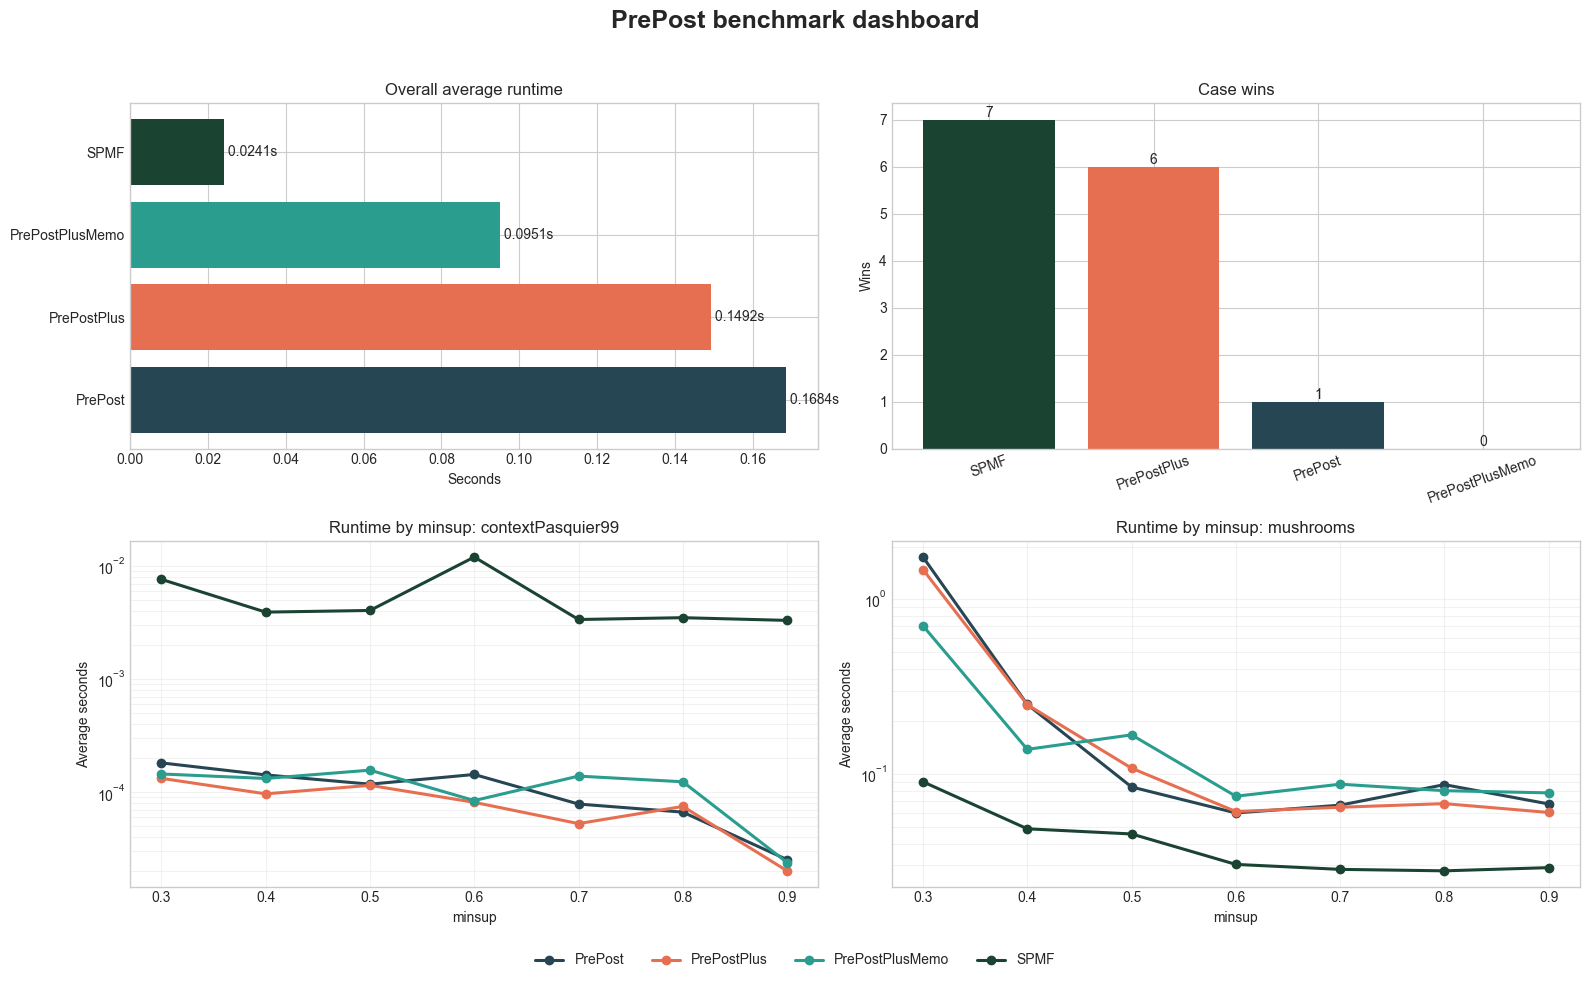

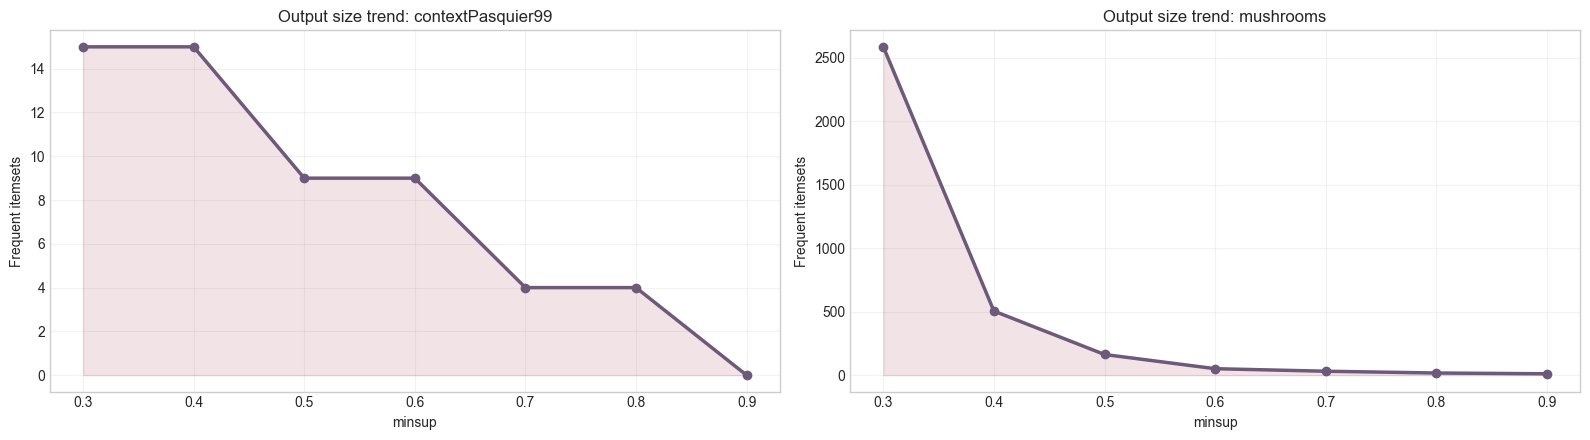

In [6]:
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")

palette = {
    "SPMF": "#1b4332",
    "PrePostPlusMemo": "#2a9d8f",
    "PrePostPlus": "#e76f51",
    "PrePost": "#264653",
}

impl_names = sorted({row["implementation"] for row in bench_rows})
overall_avg = {
    impl: mean(row["avg_seconds"] for row in bench_rows if row["implementation"] == impl)
    for impl in impl_names
}
ranking = sorted(overall_avg.items(), key=lambda item: item[1])

wins = {name: 0 for name in impl_names}
for dataset in sorted({row["dataset"] for row in bench_rows}):
    dataset_rows = [row for row in bench_rows if row["dataset"] == dataset]
    for minsup in sorted({row["minsup"] for row in dataset_rows}):
        rows_at_minsup = [row for row in dataset_rows if row["minsup"] == minsup]
        winner = min(rows_at_minsup, key=lambda row: row["avg_seconds"])
        wins[winner["implementation"]] += 1

datasets = sorted({row["dataset"] for row in bench_rows})
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("PrePost benchmark dashboard", fontsize=18, fontweight="bold")

rank_names = [name for name, _ in ranking]
rank_values = [value for _, value in ranking]
axes[0, 0].barh(
    rank_names,
    rank_values,
    color=[palette.get(name, "#888888") for name in rank_names],
)
axes[0, 0].invert_yaxis()
axes[0, 0].set_title("Overall average runtime")
axes[0, 0].set_xlabel("Seconds")
for idx, value in enumerate(rank_values):
    axes[0, 0].text(value, idx, f" {value:.4f}s", va="center", ha="left", fontsize=10)

win_names = sorted(wins, key=lambda name: (-wins[name], overall_avg[name]))
win_values = [wins[name] for name in win_names]
axes[0, 1].bar(
    win_names,
    win_values,
    color=[palette.get(name, "#888888") for name in win_names],
)
axes[0, 1].set_title("Case wins")
axes[0, 1].set_ylabel("Wins")
axes[0, 1].tick_params(axis="x", rotation=20)
for idx, value in enumerate(win_values):
    axes[0, 1].text(idx, value, str(value), ha="center", va="bottom", fontsize=10)

for ax, dataset in zip(axes[1], datasets):
    dataset_rows = [row for row in bench_rows if row["dataset"] == dataset]
    for impl in impl_names:
        impl_rows = sorted(
            [row for row in dataset_rows if row["implementation"] == impl],
            key=lambda row: row["minsup"],
        )
        ax.plot(
            [row["minsup"] for row in impl_rows],
            [row["avg_seconds"] for row in impl_rows],
            marker="o",
            linewidth=2.2,
            label=impl,
            color=palette.get(impl, "#888888"),
        )
    ax.set_title(f"Runtime by minsup: {dataset}")
    ax.set_xlabel("minsup")
    ax.set_ylabel("Average seconds")
    ax.set_yscale("log")
    ax.grid(True, which="both", alpha=0.25)

handles, labels = axes[1, 1].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=4, frameon=False, bbox_to_anchor=(0.5, 0.01))
fig.tight_layout(rect=(0, 0.05, 1, 0.96))
plt.show()

fig, axes = plt.subplots(1, len(datasets), figsize=(16, 4.5), sharey=False)
if len(datasets) == 1:
    axes = [axes]

for ax, dataset in zip(axes, datasets):
    baseline_rows = sorted(
        [
            row for row in bench_rows
            if row["dataset"] == dataset and row["implementation"] == "PrePost"
        ],
        key=lambda row: row["minsup"],
    )
    ax.plot(
        [row["minsup"] for row in baseline_rows],
        [row["output_itemsets"] for row in baseline_rows],
        marker="o",
        linewidth=2.5,
        color="#6d597a",
    )
    ax.fill_between(
        [row["minsup"] for row in baseline_rows],
        [row["output_itemsets"] for row in baseline_rows],
        color="#b56576",
        alpha=0.18,
    )
    ax.set_title(f"Output size trend: {dataset}")
    ax.set_xlabel("minsup")
    ax.set_ylabel("Frequent itemsets")
    ax.grid(True, alpha=0.25)

fig.tight_layout()
plt.show()


In [7]:
print("=== Output equality check across implementations ===")
all_ok = True
for case_key, case_outputs in outputs_by_case.items():
    implementation_outputs = {
        name: output
        for name, output in case_outputs.items()
        if isinstance(output, dict)
    }
    names = list(implementation_outputs.keys())
    base_name = names[0]
    base_output = implementation_outputs[base_name]
    differing = [name for name in names[1:] if implementation_outputs[name] != base_output]
    equal = not differing
    status = "OK" if equal else f"DIFF ({', '.join(differing)})"
    print(f"{case_key}: {status}")
    all_ok = all_ok and equal

if not all_ok:
    raise AssertionError('At least one case returned different outputs between implementations.')

print('All implementations returned identical outputs for all configured cases.')

=== Output equality check across implementations ===
contextPasquier99|minsup=0.3: OK
contextPasquier99|minsup=0.4: OK
contextPasquier99|minsup=0.5: OK
contextPasquier99|minsup=0.6: OK
contextPasquier99|minsup=0.7: OK
contextPasquier99|minsup=0.8: OK
contextPasquier99|minsup=0.9: OK
mushrooms|minsup=0.3: OK
mushrooms|minsup=0.4: OK
mushrooms|minsup=0.5: OK
mushrooms|minsup=0.6: OK
mushrooms|minsup=0.7: OK
mushrooms|minsup=0.8: OK
mushrooms|minsup=0.9: OK
All implementations returned identical outputs for all configured cases.


In [8]:
SHOW_SAMPLE_MINSUP = 0.4

print("=== Itemset count trend (PrePost baseline) ===")
for dataset in sorted({row["dataset"] for row in bench_rows}):
    baseline_rows = [
        row for row in bench_rows
        if row["dataset"] == dataset and row["implementation"] == "PrePost"
    ]
    baseline_rows.sort(key=lambda r: r["minsup"])
    print(
        f"{dataset:18} -> " + ", ".join(
            f"{r['minsup']:.1f}:{r['output_itemsets']}" for r in baseline_rows
        )
    )

print("\n=== Sample outputs (first 10 lines) ===")
for case_key in sorted(outputs_by_case):
    if f"minsup={SHOW_SAMPLE_MINSUP:.1f}" not in case_key:
        continue
    print("\n" + case_key)
    sample_itemsets = next(iter(outputs_by_case[case_key].values()))
    sample_formatted = format_itemsets(sorted(sample_itemsets.items())).splitlines()[:10]
    for line in sample_formatted:
        print(line)

=== Itemset count trend (PrePost baseline) ===
contextPasquier99  -> 0.3:15, 0.4:15, 0.5:9, 0.6:9, 0.7:4, 0.8:4, 0.9:0
mushrooms          -> 0.3:2587, 0.4:505, 0.5:163, 0.6:51, 0.7:31, 0.8:17, 0.9:11

=== Sample outputs (first 10 lines) ===

contextPasquier99|minsup=0.4
1 #SUP: 3
1 2 #SUP: 2
1 2 3 #SUP: 2
1 2 3 5 #SUP: 2
1 2 5 #SUP: 2
1 3 #SUP: 3
1 3 5 #SUP: 2
1 5 #SUP: 2
2 #SUP: 4
2 3 #SUP: 3

mushrooms|minsup=0.4
1 #SUP: 4488
1 31 #SUP: 3688
1 31 36 #SUP: 3496
1 31 36 90 #SUP: 3496
1 31 36 90 94 #SUP: 3496
1 31 36 94 #SUP: 3496
1 31 41 #SUP: 3472
1 31 41 90 #SUP: 3472
1 31 90 #SUP: 3688
1 31 90 94 #SUP: 3496
